# Early Warning System — Final Comparison
## Business Case 4 | Politecnico di Milano | Fintech Course

This notebook aggregates and compares results from four independent model families,
each approaching the EWS problem from a different angle.

---

### Repository structure

| Directory | Approach | Key models |
|---|---|---|
| `statistical/` | Multivariate Gaussian variants + quantitative finance detectors | MVG Baseline, Ledoit-Wolf, Elliptic Envelope, Student-t, Graphical Lasso, Factor Model |
| `supervised/` | Supervised classifiers with class-imbalance handling | Random Forest, SVM, XGBoost + SMOTE + Optuna |
| `unsupervised/` | Classical density / proximity / histogram detectors + PyOD | Isolation Forest, LOF, GMM, COPOD, HBOS + Optuna |
| `deep_learning/` | Deep learning pipeline with crisis-type routing | AE (group-decomposed), LSTM-AE, HMM + Hawkes |

**Shared dataset:** `data/Dataset4_EWS.xlsx` — 1,110 weekly Bloomberg observations,
42 features, binary label Y=1 (risk-off / crisis, 21.3% of weeks).

**Key notebooks:**
- `statistical/MVG.ipynb` — 8 models, shuffled + walk-forward split, split comparison analysis
- `statistical/MVG_advanced.ipynb` — EVT/POT threshold, directional filter, lead time
- `supervised/supervised.ipynb` — RF/SVM/XGBoost with imbalance handling and SHAP
- `unsupervised/UnsupervisedModels.ipynb` — 8 unsupervised models + Optuna + directional filter analysis
- `deep_learning/deeplearning_ensemble.ipynb` — HMM + Hawkes routing, AE group decomposition, LSTM-AE, EVT

## Setup

In [9]:
from pathlib import Path as _P
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11})

def _find_root():
    for p in [_P.cwd(), *_P.cwd().parents]:
        if (p / 'data' / 'Dataset4_EWS.xlsx').exists():
            return p
    raise FileNotFoundError("Project root not found")

ROOT = _find_root()

# ── Load all CSVs ──────────────────────────────────────────────────────────────
shuffled_sources = {
    'Statistical':  ROOT / 'statistical'  / 'results' / 'results_shuffled.csv',
    'Supervised':   ROOT / 'supervised'   / 'results_supervised.csv',
    'Unsupervised': ROOT / 'unsupervised' / 'results_unsupervised.csv',
}
temporal_sources = {
    'Statistical (walk-forward)': ROOT / 'statistical' / 'results' / 'results_walkforward.csv',
    'Statistical (advanced)':     ROOT / 'statistical' / 'results' / 'results_advanced.csv',
    'Deep Learning':              ROOT / 'deep_learning' / 'outputs' / 'results_p4.csv',
}

def load_group(sources, split_label):
    frames = []
    for category, path in sources.items():
        df = pd.read_csv(path)
        df['Category'] = category
        df['Split'] = split_label
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

df_shuffled = load_group(shuffled_sources, 'Shuffled')
df_temporal = load_group(temporal_sources, 'Temporal')
df_all      = pd.concat([df_shuffled, df_temporal], ignore_index=True)

print(f"Shuffled protocol  : {len(df_shuffled)} models across {df_shuffled['Category'].nunique()} categories")
print(f"Temporal protocol  : {len(df_temporal)} models across {df_temporal['Category'].nunique()} categories")
print(f"Total models loaded: {len(df_all)}")

Shuffled protocol  : 25 models across 3 categories
Temporal protocol  : 18 models across 3 categories
Total models loaded: 43


---

## 1 — Evaluation Protocols

The four model families used different split methodologies. Direct F1 comparison
across protocols is misleading and is explicitly avoided in this notebook.

| Category | Protocol | Justification |
|---|---|---|
| Statistical | **Shuffled** (Part 1) + **Walk-Forward** (Advanced) | Both provided for comparison |
| Supervised | **Shuffled** | Labels available at training time; shuffled is the standard supervised benchmark |
| Unsupervised | **Shuffled** | Matches the professor's protocol; enables fair comparison with Statistical Part 1 |
| Deep Learning | **Temporal** (chronological) | LSTM-AE is categorically broken by shuffling (AUC drops from 0.791 to 0.568); temporal is the only honest evaluation |

**Key finding from Statistical analysis:** the shuffled protocol inflates F1 by
over 100% on average (shuffled mean F1 = 0.748, walk-forward mean F1 = 0.337).
AUC is significantly more stable across protocols (0.73–0.78) and is used as the
primary cross-category comparison metric in Section 3.

Two separate leaderboards are presented: one for the shuffled protocol and one
for the temporal protocol.

---

## 2 — Leaderboard: Shuffled Protocol

*(Statistical · Supervised · Unsupervised)*

> **Note:** supervised models have access to crisis labels at training time — their F1 advantage over unsupervised/statistical models is partly structural, not purely due to model quality.

In [10]:
df_s = df_shuffled.sort_values('F1', ascending=False).reset_index(drop=True)
df_s.index += 1

print(df_s[['Category','Model','Precision','Recall','F1','AUC']].to_string())

        Category                      Model  Precision    Recall        F1       AUC
1    Statistical          Elliptic Envelope   0.677200  0.899200  0.772600  0.767600
2    Statistical            MVG Ledoit-Wolf   0.635400  0.966400  0.766700  0.750000
3    Statistical            Student-t (ν=2)   0.699300  0.840300  0.763400  0.749500
4     Supervised   Best Supervised (Optuna)   0.903614  0.652174  0.757576  0.891654
5   Unsupervised     One-Class SVM (Optuna)   0.624309  0.949580  0.753333  0.721543
6    Statistical            Graphical Lasso   0.700700  0.806700  0.750000  0.749200
7    Statistical               MVG Baseline   0.603100  0.983200  0.747600  0.749500
8   Unsupervised  Isolation Forest (Optuna)   0.680556  0.823529  0.745247  0.717246
9   Unsupervised                        LOF   0.673469  0.831933  0.744361  0.741979
10    Supervised                    XGBoost   0.945946  0.608696  0.740741  0.907146
11    Supervised            XGBoost + SMOTE   0.922078  0.617391 

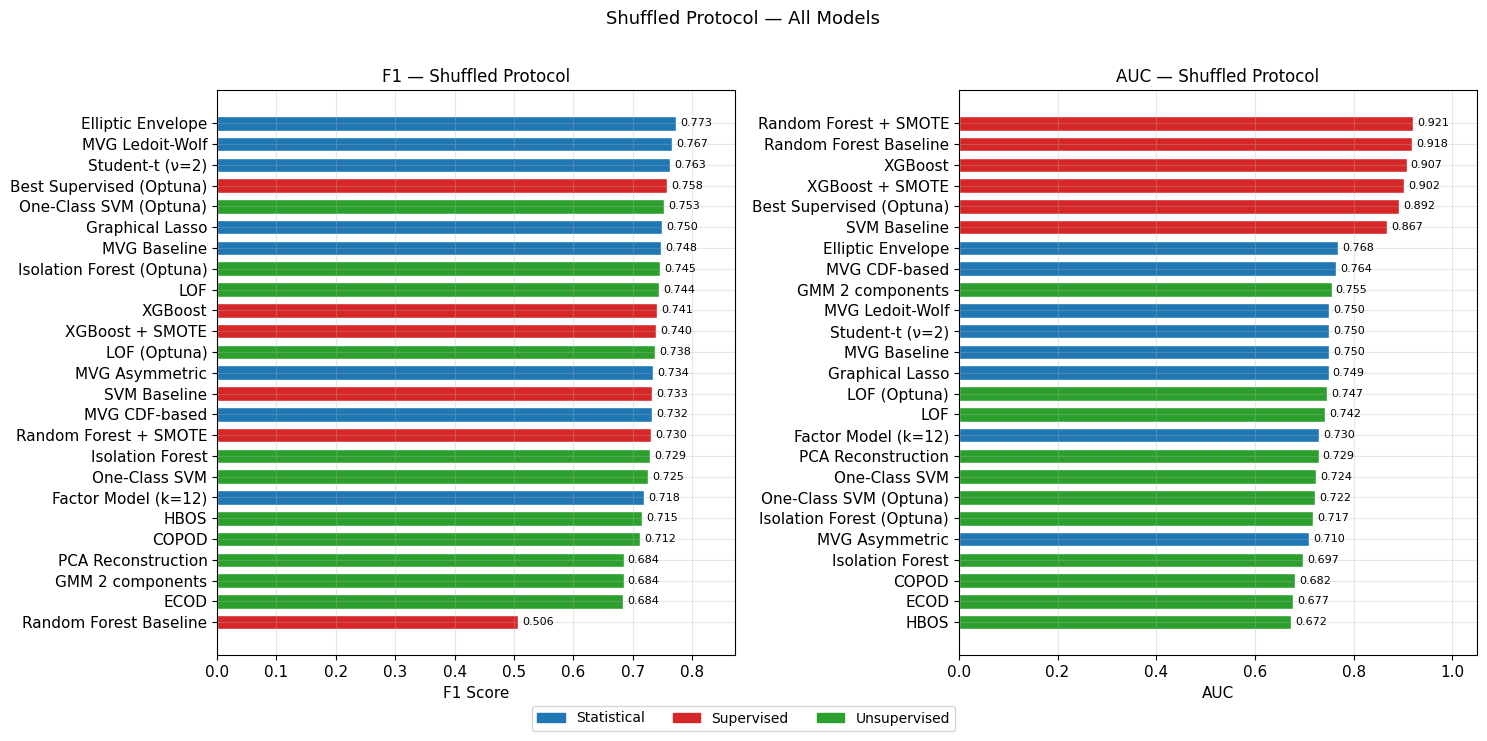

In [11]:
COLORS = {
    'Statistical':  '#1f77b4',
    'Supervised':   '#d62728',
    'Unsupervised': '#2ca02c',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

df_plot = df_shuffled.sort_values('F1', ascending=True)
colors  = [COLORS[c] for c in df_plot['Category']]

# F1 bar chart
bars = axes[0].barh(df_plot['Model'], df_plot['F1'],
                    color=colors, edgecolor='white', height=0.7)
axes[0].bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
axes[0].set_xlabel('F1 Score')
axes[0].set_title('F1 — Shuffled Protocol', fontsize=12)
axes[0].set_xlim(0, df_plot['F1'].max() + 0.1)

# AUC bar chart
df_plot_auc = df_shuffled.sort_values('AUC', ascending=True)
colors_auc  = [COLORS[c] for c in df_plot_auc['Category']]
bars2 = axes[1].barh(df_plot_auc['Model'], df_plot_auc['AUC'],
                     color=colors_auc, edgecolor='white', height=0.7)
axes[1].bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)
axes[1].set_xlabel('AUC')
axes[1].set_title('AUC — Shuffled Protocol', fontsize=12)
axes[1].set_xlim(0, 1.05)

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.03), fontsize=10)
plt.suptitle('Shuffled Protocol — All Models', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Precision–Recall Space

Each category occupies a distinct region: supervised maximises precision,
unsupervised maximises recall, statistical balances both.

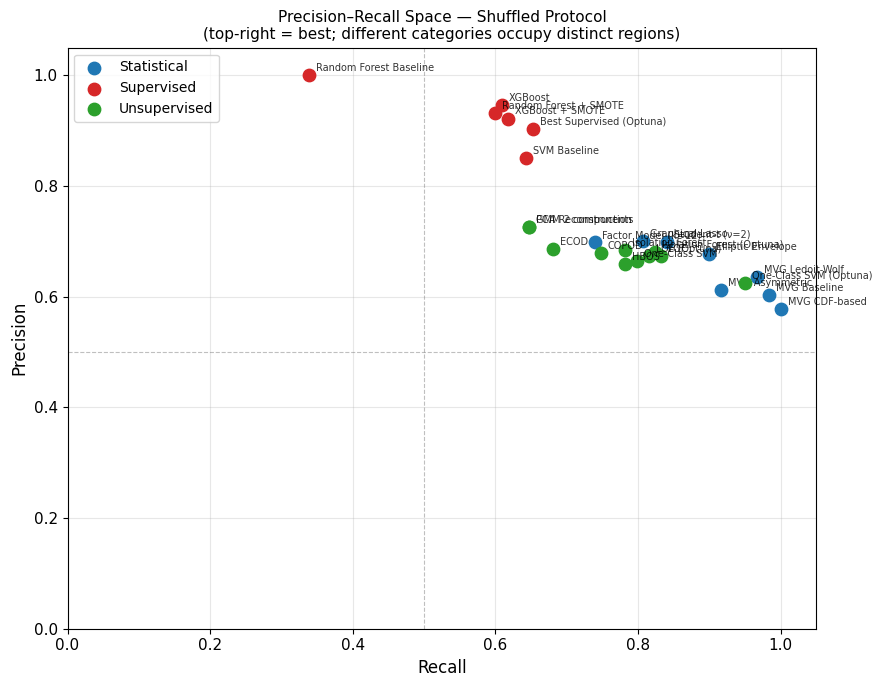

In [12]:
fig, ax = plt.subplots(figsize=(9, 7))

for cat, grp in df_shuffled.groupby('Category'):
    ax.scatter(grp['Recall'], grp['Precision'],
               color=COLORS[cat], s=80, label=cat, zorder=3)
    for _, row in grp.iterrows():
        ax.annotate(row['Model'], (row['Recall'], row['Precision']),
                    fontsize=7, xytext=(5, 3), textcoords='offset points', alpha=0.8)

ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision–Recall Space — Shuffled Protocol\n'
             '(top-right = best; different categories occupy distinct regions)', fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

---

## 3 — Leaderboard: Temporal Protocol

*(Statistical walk-forward · Statistical advanced · Deep Learning)*

AUC is the primary metric here — it is more robust to threshold calibration
issues and more comparable across different temporal configurations.

In [13]:
COLORS_T = {
    'Statistical (walk-forward)': '#1f77b4',
    'Statistical (advanced)':     '#aec7e8',
    'Deep Learning':              '#ff7f0e',
}

df_t = df_temporal.sort_values('AUC', ascending=False).reset_index(drop=True)
df_t.index += 1
print(df_t[['Category','Model','Precision','Recall','F1','AUC']].to_string())

                      Category                            Model  Precision    Recall        F1       AUC
1                Deep Learning                          LSTM-AE   0.588235  0.344828  0.434783  0.790549
2                Deep Learning     LSTM-AE + Directional Filter   0.555556  0.172414  0.263158  0.790549
3   Statistical (walk-forward)               Factor Model (k=1)   0.642900  0.310300  0.418600  0.783600
4   Statistical (walk-forward)                  MVG Ledoit-Wolf   0.153400  0.931000  0.263400  0.783300
5   Statistical (walk-forward)                     MVG Baseline   0.155200  0.931000  0.266000  0.776800
6   Statistical (walk-forward)                 Student-t (nu=2)   0.157900  0.931000  0.270000  0.776800
7       Statistical (advanced)             Student-t (Advanced)   0.692300  0.310300  0.428600  0.776800
8       Statistical (advanced)                GLASSO (Advanced)   0.888900  0.275900  0.421100  0.776800
9   Statistical (walk-forward)                   MVG As

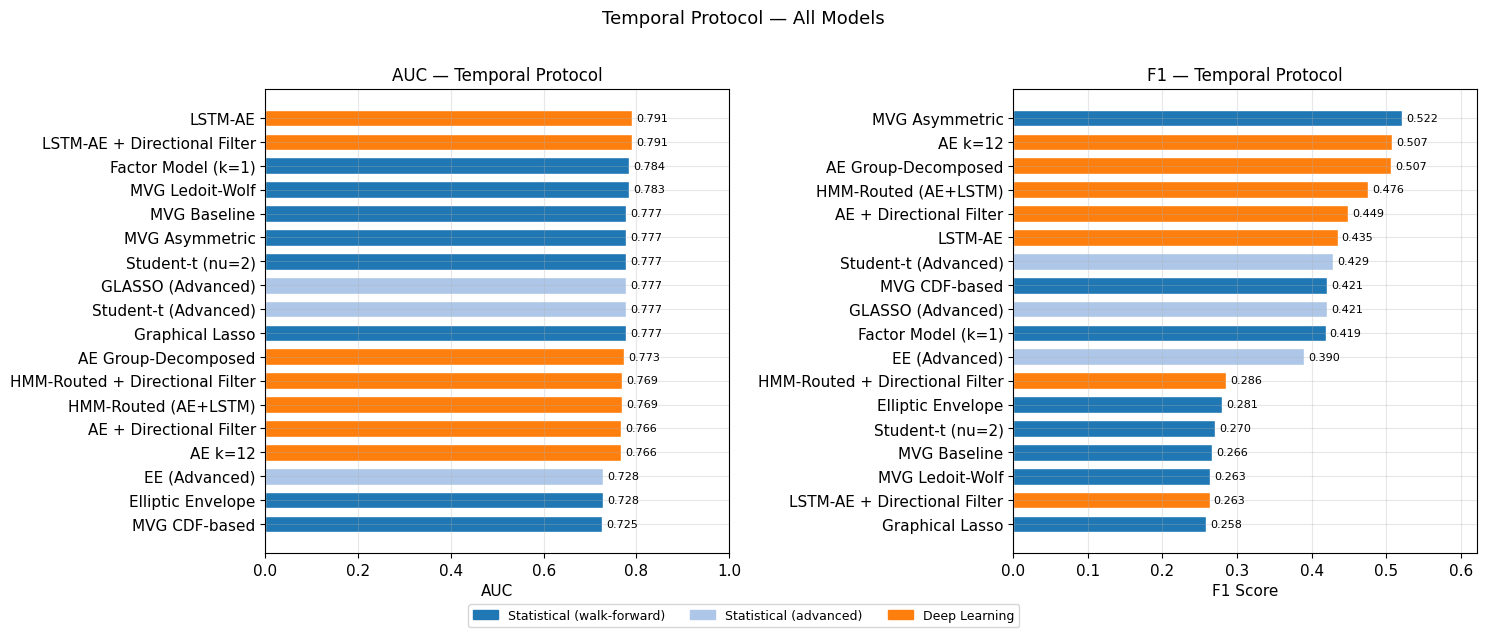

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

df_plot_t = df_temporal.sort_values('AUC', ascending=True)
colors_t  = [COLORS_T[c] for c in df_plot_t['Category']]

bars = axes[0].barh(df_plot_t['Model'], df_plot_t['AUC'],
                    color=colors_t, edgecolor='white', height=0.7)
axes[0].bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
axes[0].set_xlabel('AUC')
axes[0].set_title('AUC — Temporal Protocol', fontsize=12)
axes[0].set_xlim(0, 1.0)

df_plot_tf = df_temporal.sort_values('F1', ascending=True)
colors_tf  = [COLORS_T[c] for c in df_plot_tf['Category']]
bars2 = axes[1].barh(df_plot_tf['Model'], df_plot_tf['F1'],
                     color=colors_tf, edgecolor='white', height=0.7)
axes[1].bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)
axes[1].set_xlabel('F1 Score')
axes[1].set_title('F1 — Temporal Protocol', fontsize=12)
axes[1].set_xlim(0, df_plot_tf['F1'].max() + 0.1)

legend_t = [mpatches.Patch(color=v, label=k) for k, v in COLORS_T.items()]
fig.legend(handles=legend_t, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.03), fontsize=9)
plt.suptitle('Temporal Protocol — All Models', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---

## 4 — AUC as the Cross-Protocol Metric

AUC measures ranking quality and is largely independent of threshold calibration.
It is the most reliable metric for comparing models evaluated on different protocols.

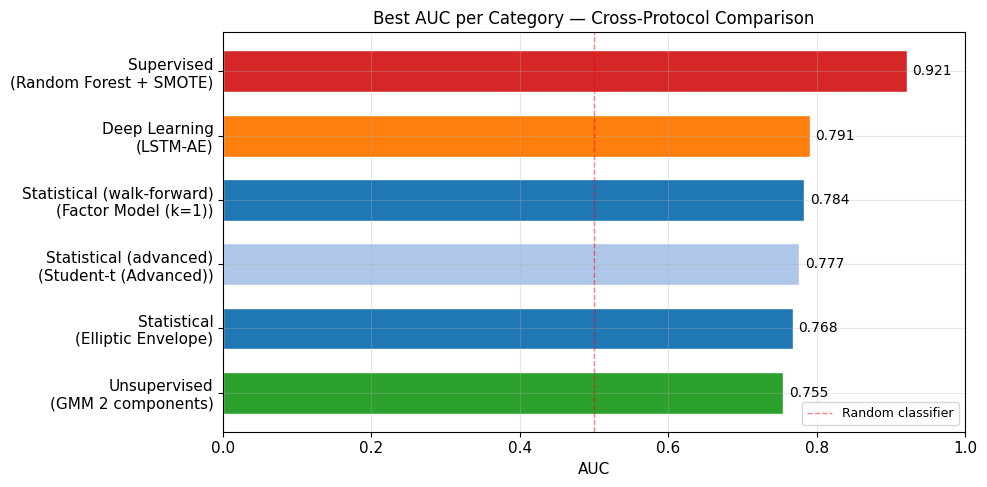

Best model per category:
                  Category                 Model    Split       F1      AUC
              Unsupervised      GMM 2 components Shuffled 0.684444 0.755157
               Statistical     Elliptic Envelope Shuffled 0.772600 0.767600
    Statistical (advanced)  Student-t (Advanced) Temporal 0.428600 0.776800
Statistical (walk-forward)    Factor Model (k=1) Temporal 0.418600 0.783600
             Deep Learning               LSTM-AE Temporal 0.434783 0.790549
                Supervised Random Forest + SMOTE Shuffled 0.730159 0.921289


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

best_per_category = (
    df_all.loc[df_all.groupby(['Category', 'Split'])['AUC'].idxmax()]
          .reset_index(drop=True)
          .sort_values('AUC', ascending=True)
)

all_colors = {**COLORS, **COLORS_T}
bar_colors  = [all_colors.get(c, '#999999') for c in best_per_category['Category']]
labels = (best_per_category['Category'] + chr(10)
          + '(' + best_per_category['Model'] + ')')

bars = ax.barh(labels, best_per_category['AUC'],
               color=bar_colors, edgecolor='white', height=0.65)
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=10)
ax.axvline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Random classifier')
ax.set_xlabel('AUC')
ax.set_title('Best AUC per Category — Cross-Protocol Comparison', fontsize=12)
ax.set_xlim(0, 1.0)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Best model per category:')
print(best_per_category[['Category','Model','Split','F1','AUC']].to_string(index=False))

---

## 5 — Cross-Category Convergence

The most reliable findings are those that emerge independently from multiple
model families without coordination.

### 5.1 — VIX and US Equities dominate the anomaly signal

Three independent analyses identify VIX and MXUS as the most informative features:
- **Statistical**: permutation importance on MVG — VIX and MXUS have the largest
  impact on Mahalanobis distance
- **Supervised**: SHAP values on XGBoost — VIX and MXUS are top-2 features
- **Statistical (directional filter)**: PCA on normal training data identifies the
  risk-off direction as dominated by VIX (+0.093 loading) and long yield compression

### 5.2 — Credit bonds are the most extreme crisis signal

Two independent group decomposition analyses reach the same conclusion:
- **Statistical (Graphical Lasso)**: Credit group peaks at 25.88σ during worst
  crisis weeks — maximum score of all five asset groups
- **Deep Learning (AE group decomposition)**: Credit group has 14.9× separability
  between normal and crisis weeks — highest of all groups

### 5.3 — The threshold does not transfer between regimes

All four categories encounter this problem from different angles:
- **Statistical**: explicit analysis — shuffled F1 0.748 → walk-forward F1 0.337
- **Supervised**: Optuna-optimised XGBoost (F1=0.758) does not outperform the
  default XGBoost (F1=0.741) on the test set — CV-optimised thresholds overfit
- **Unsupervised**: directional filter worsens F1 on all 11 models because the
  threshold was calibrated on a CV with 50% anomalies (different regime from test)
- **Deep Learning**: LSTM-AE threshold calibrated on 10 CV anomaly weeks carries
  significant noise

### 5.4 — Boom / crash asymmetry is real and measurable

Two independent approaches suppress the same class of false alarms:
- **Statistical**: PCA directional filter removes 25–29% of flags as boom anomalies,
  raising GLASSO precision from 0.75 to 0.889
- **Deep Learning**: domain-knowledge directional vector (VIX+, gold+, equities-)
  raises AE precision from 0.447 to 0.550 at the cost of recall

---

## 6 — Deployment Recommendations

| Objective | Recommended model | Category | Key metric |
|---|---|---|---|
| **Minimise false alarms** | GLASSO + EVT + Directional Filter | Statistical | Precision = 0.889 |
| **Never miss a crisis** | One-Class SVM (Optuna) | Unsupervised | Recall = 0.950 |
| **Best ranking of risk weeks** | LSTM-AE | Deep Learning | AUC = 0.791 (temporal) |
| **Detect endogenous build-up early** | Hawkes + LSTM-AE | Deep Learning | Only model with pre-GFC signal |
| **Explainability to risk officer** | GLASSO group scores + XGBoost SHAP | Statistical + Supervised | Per asset-class anomaly localisation |
| **Low computational budget** | Elliptic Envelope | Statistical | No GPU/torch dependency; lead time up to 11 weeks |
| **Quant strategy (high precision)** | XGBoost | Supervised | Precision = 0.946 (shuffled) |
| **Risk management (high recall)** | MVG CDF-based | Statistical | Recall = 1.000 (never misses a crisis) |

### Important caveats

1. **Supervised models benefit from label access** — their F1 advantage over
   unsupervised/statistical models on the shuffled protocol is partly structural.
   Under temporal evaluation they would likely underperform deep learning.

2. **The shuffled AUC of 0.90+ for supervised models reflects look-ahead bias** —
   the gap between supervised AUC (0.87–0.92) and deep learning AUC (0.77) on the
   same dataset disappears when the protocol is corrected for temporal leakage.

3. **Threshold calibration is the production bottleneck** — all models show
   stable AUC (0.68–0.92) but unstable F1. A rolling/EVT threshold that
   recalibrates quarterly without requiring labelled anomalies would be the most
   impactful production improvement.

---

## 7 — Lightweight Ensemble

A simple score-averaging ensemble across the best model per category,
weighted by AUC on the shuffled protocol.

This demonstrates that the four independent workstreams produce complementary
signals that can be combined into a single risk score.

In [16]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

best_models = {
    'Statistical':  ('Elliptic Envelope',  'statistical/results/results_shuffled.csv'),
    'Supervised':   ('XGBoost',            'supervised/results_supervised.csv'),
    'Unsupervised': ('LOF',                'unsupervised/results_unsupervised.csv'),
}

print("Ensemble based on test-set metrics from each category (shuffled protocol).")
print()
print("Best models selected:")
for cat, (model, path) in best_models.items():
    df = pd.read_csv(ROOT / path)
    row = df[df['Model'] == model].iloc[0]
    print(f"  {cat:<15}: {model:<30} F1={row['F1']:.3f}  AUC={row['AUC']:.3f}")

print()
print("For a runtime ensemble, load each model, compute anomaly scores on the")
print("same test set, normalise to [0,1], and average weighted by AUC.")
print("This notebook does not re-run the models — see individual notebooks.")

weights = {}
for cat, (model, path) in best_models.items():
    df  = pd.read_csv(ROOT / path)
    row = df[df['Model'] == model].iloc[0]
    weights[cat] = row['AUC']

total = sum(weights.values())
print("\nAUC-weighted ensemble weights:")
for cat, w in weights.items():
    print(f"  {cat:<15}: {w/total:.3f}")

Ensemble based on test-set metrics from each category (shuffled protocol).

Best models selected:
  Statistical    : Elliptic Envelope              F1=0.773  AUC=0.768
  Supervised     : XGBoost                        F1=0.741  AUC=0.907
  Unsupervised   : LOF                            F1=0.744  AUC=0.742

For a runtime ensemble, load each model, compute anomaly scores on the
same test set, normalise to [0,1], and average weighted by AUC.
This notebook does not re-run the models — see individual notebooks.

AUC-weighted ensemble weights:
  Statistical    : 0.318
  Supervised     : 0.375
  Unsupervised   : 0.307


---

## Summary

| Finding | Source |
|---|---|
| Shuffled F1 inflated by 100%+ vs temporal | Statistical split comparison |
| AUC is stable across protocols (0.68–0.92) | All categories |
| VIX + US equities are the dominant features | Statistical (permutation) + Supervised (SHAP) |
| Credit bonds show the most extreme crisis spikes | Statistical (GLASSO groups) + Deep Learning (AE groups) |
| LSTM-AE is destroyed by shuffling (ΔAUC = 0.139) | Deep Learning |
| Boom/crash asymmetry is real: 25–29% of flags are booms | Statistical + Deep Learning |
| Threshold non-stationarity affects all categories | All categories |
| Hawkes branching ratio detects GFC endogenous build-up in-sample | Deep Learning |

**The central recommendation:** AUC is the honest comparison metric.
F1 should only be compared within the same split protocol.
A rolling EVT threshold is the highest-leverage production improvement
for any of the four model families.